# Stage 0b - Image Augmentation Preview
D12 CIFAR-10 uses image augmentation on training images only.

In [1]:


import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/a213696/Group-5-ML-Project.git"
REPO_NAME = "Group-5-ML-Project"

CURRENT = Path.cwd()

if (CURRENT / "src").exists():
    PROJECT_ROOT = CURRENT

elif CURRENT.name == "notebooks" and (CURRENT.parent / "src").exists():
    PROJECT_ROOT = CURRENT.parent

else:
    BASE_DIR = Path("/content") if Path("/content").exists() else CURRENT
    PROJECT_ROOT = BASE_DIR / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning repository from GitHub...")
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_ROOT)], check=True)
    else:
        print("Repository already exists. Pulling latest version...")
        subprocess.run(["git", "-C", str(PROJECT_ROOT), "pull"], check=False)

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / "artifacts" / "figures"
TABLE_DIR = PROJECT_ROOT / "artifacts" / "tables"
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
for d in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())
print("src exists:", (PROJECT_ROOT / "src").exists())
print("notebooks exists:", (PROJECT_ROOT / "notebooks").exists())

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("The src folder is missing. Upload src to GitHub or clone the full project repository, not only one notebook.")

import numpy as np, matplotlib.pyplot as plt
from src.data import load_cifar10, set_seeds, CLASSES
from src.augment import build_augmentation_layers
set_seeds(42)



Cloning repository from GitHub...
Project root: /content/Group-5-ML-Project
Current working directory: /content/Group-5-ML-Project
src exists: True
notebooks exists: False


In [2]:
aug = build_augmentation_layers()
aug.summary()

Model: "augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_crop (RandomCrop)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


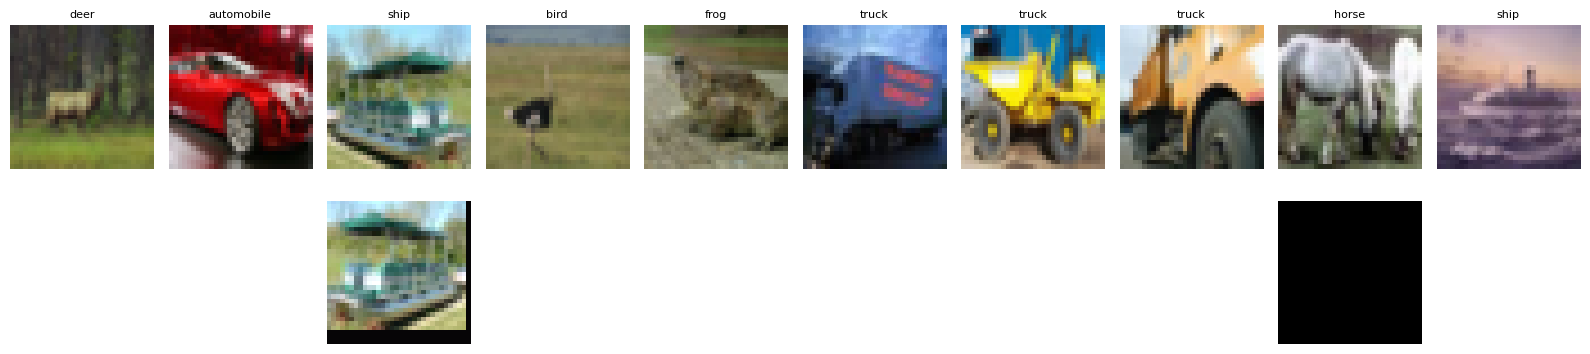

In [3]:
x_train, y_train, x_test, y_test = load_cifar10()
idx = np.random.default_rng(42).choice(len(x_train), 10, replace=False)
original = x_train[idx].astype("float32") / 255.0
augmented = aug(original, training=True).numpy()
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i in range(10):
    axes[0,i].imshow(original[i]); axes[0,i].axis("off"); axes[0,i].set_title(CLASSES[y_train[idx[i]]], fontsize=8)
    axes[1,i].imshow(np.clip(augmented[i],0,1)); axes[1,i].axis("off")
axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Augmented")
plt.tight_layout(); plt.savefig(FIG_DIR / "stage0b_augmentation_preview.png", dpi=150); plt.show()

## Leakage guardrail
Augmentation is applied only to training images. Validation and test images are not augmented because evaluation data must stay unchanged. This prevents leakage and gives a fair estimate of performance on unseen images.